In [ ]:
! pip install ISLP
from ISLP import load_data
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 704.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 4.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=92e4eeba0ada2e283a4c1dfb34b65fa9970b1715618ac758461d91ed257a71d3
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
  Attempting 

Exercise 13
(a) answer :

In [ ]:
data = pd.read_csv("https://www.statlearning.com/s/Ch12Ex13.csv", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-0.961933,0.441803,-0.975005,1.417504,0.818815,0.316294,-0.024967,-0.063966,0.031497,-0.350311,...,-0.509591,-0.216725,-0.055506,-0.484449,-0.521581,1.949135,1.324335,0.468147,1.061100,1.655970
1,-0.292526,-1.139267,0.195837,-1.281121,-0.251439,2.511997,-0.922206,0.059543,-1.409645,-0.656712,...,1.700708,0.007290,0.099062,0.563853,-0.257275,-0.581781,-0.169887,-0.542304,0.312939,-1.284377
2,0.258788,-0.972845,0.588486,-0.800258,-1.820398,-2.058924,-0.064764,1.592124,-0.173117,-0.121087,...,-0.615472,0.009999,0.945810,-0.318521,-0.117889,0.621366,-0.070764,0.401682,-0.016227,-0.526553
3,-1.152132,-2.213168,-0.861525,0.630925,0.951772,-1.165724,-0.391559,1.063619,-0.350009,-1.489058,...,-0.284277,0.198946,-0.091833,0.349628,-0.298910,1.513696,0.671185,0.010855,-1.043689,1.625275
4,0.195783,0.593306,0.282992,0.247147,1.978668,-0.871018,-0.989715,-1.032253,-1.109654,-0.385142,...,-0.692998,-0.845707,-0.177497,-0.166491,1.483155,-1.687946,-0.141430,0.200778,-0.675942,2.220611


(b) Hierarchical Clustering and Dendrograms

In [ ]:
#Before doing hierchical clustering ,transposing the dataframe for meaningful results so that genes should be attributes of each patient.
data=data.T

<Figure size 640x480 with 0 Axes>

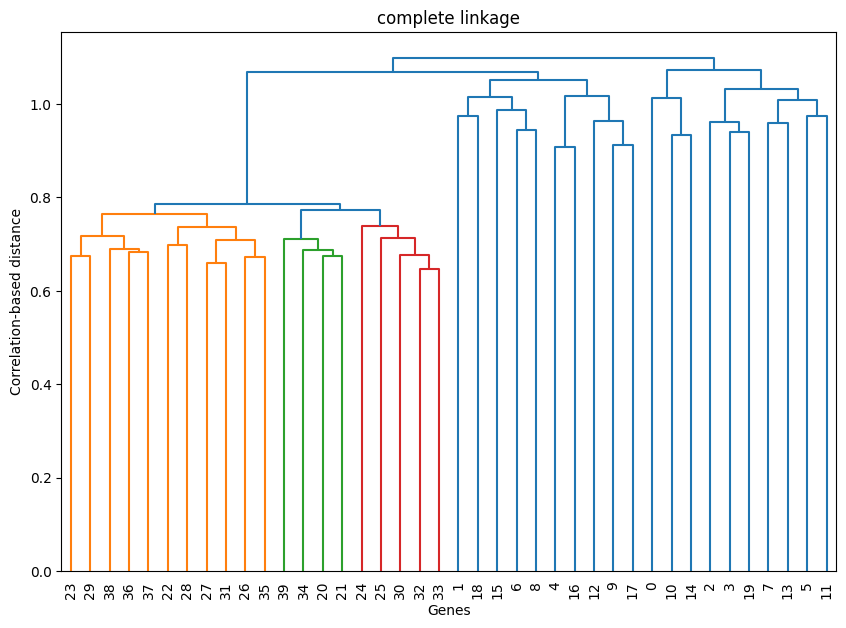

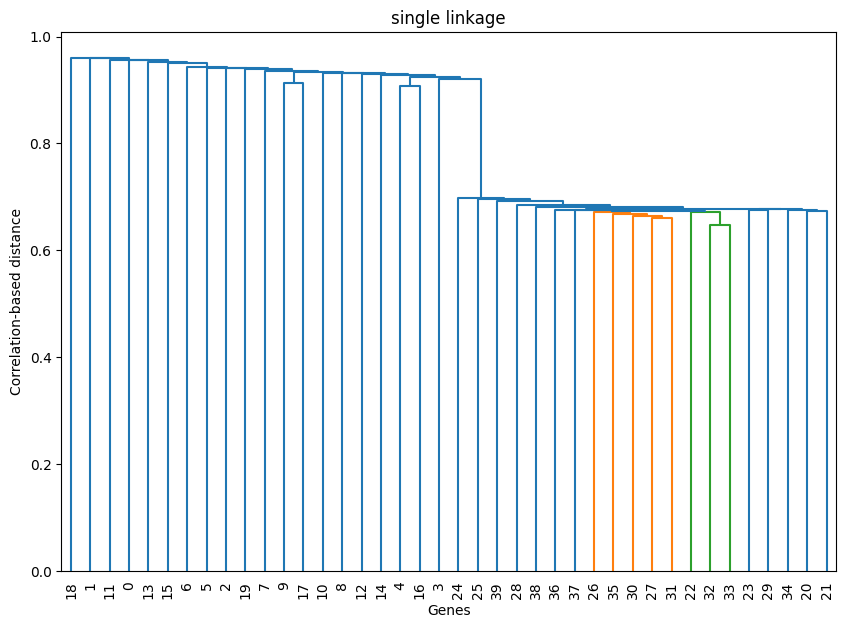

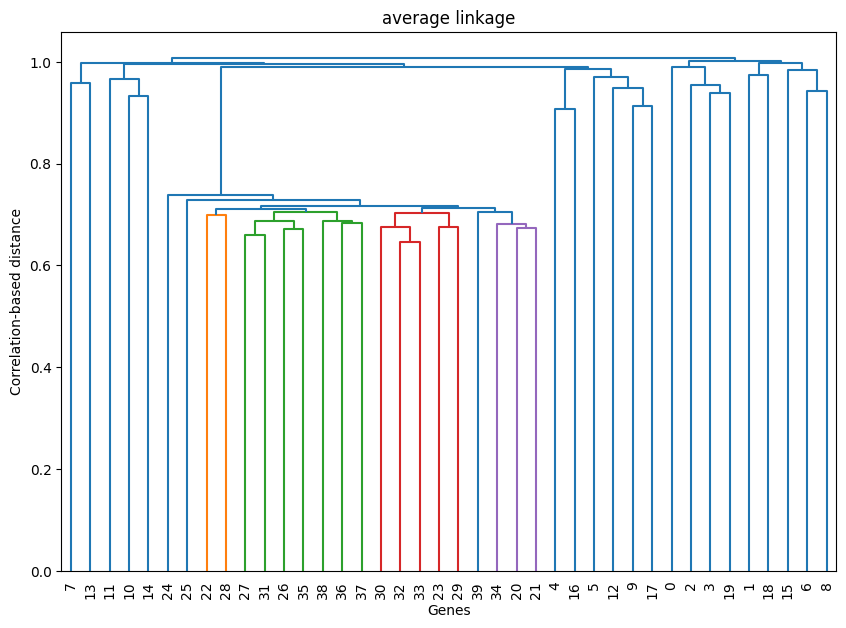

In [ ]:
#apply hierarchical clustering with different linkage methods (complete, average, and single) and plot the dendrograms.
linkages = ['complete', 'single', 'average']
H_clustering_methods = []

for i, l in zip(range(4), linkages):
    HC = linkage(y=data, method=l, metric='correlation')
    H_clustering_methods.append(HC)
    plt.figure(i)
    plt.figure(figsize=(10, 7))
    plt.title('%s linkage' % l)
    plt.xlabel('Genes')
    plt.ylabel('Correlation-based distance')
    dendrogram(HC, labels=data.index, leaf_rotation=90, leaf_font_size=10)

Analyzing Clustering Results

In [ ]:
# Create DataFrames with cluster assignments for each linkage type
from scipy.cluster.hierarchy import cut_tree

# Complete linkage results
complete = pd.DataFrame(cut_tree(H_clustering_methods[0], n_clusters=2))
complete.index.name = 'patients'
complete.rename(columns={0: 'Complete'}, inplace=True)

# Single linkage results
single = pd.DataFrame(cut_tree(H_clustering_methods[1], n_clusters=2))
single.index.name = 'patients'
single.rename(columns={0: 'Single'}, inplace=True)

# Average linkage results
average = pd.DataFrame(cut_tree(H_clustering_methods[2], n_clusters=2))
average.index.name = 'patients'
average.rename(columns={0: 'Average'}, inplace=True)

# Combine results into a single DataFrame
dataframes = [complete, single, average]
data_new = dataframes[0].join(dataframes[1:])
data_new


,Complete,Single,Average
patients,,,
0,0,0,0
1,1,0,0
2,0,0,0
3,0,0,0
4,1,0,1
5,0,0,1
6,1,0,0
7,0,0,1
8,1,0,0


Based on the dendrograms and the cluster assignments for each linkage type, here's the analysis of how well each linkage method (complete, average, and single) separates the data into two clusters and whether the genes separate the samples into the two groups:

Complete Linkage:

The complete linkage dendrogram shows two main clusters, with relatively distinct subclusters within each of the two main clusters.
The cluster assignment output shows a mix of 0 and 1 labels for samples within each group, indicating some overlap in cluster assignment.
However, complete linkage provides better separation than single linkage, as there are distinct branches that group similar samples, suggesting that some differentiation between the healthy and diseased samples may be achieved.

Single Linkage:

The single linkage dendrogram has long chains with limited separation, as the single linkage method often causes clusters to merge quickly due to its minimal distance criteria.
The cluster assignment for single linkage shows all samples in one main cluster (0) with only a few exceptions, indicating poor separation.
This linkage type does not effectively separate the samples into two distinct groups, as it tends to chain samples together without clear boundaries.

Average Linkage:

The average linkage dendrogram shows moderately distinct clusters, with less chaining than single linkage and more gradual merging than complete linkage.
The cluster assignment output for average linkage has a clearer distribution of 0 and 1 labels compared to single linkage, but still has some mixed clusters.
Average linkage provides a balance between complete and single linkage, creating clusters that are more meaningful but not as distinct as complete linkage.

Conclusion:

Linkage Dependence:
The clustering results do depend on the linkage type used. Complete linkage gives the best separation among the three, while single linkage performs the worst in separating healthy and diseased samples.

Separation of Samples:
None of the linkage types completely separates the samples into the two distinct groups (healthy and diseased) as labeled. However, complete and average linkages show some separation, with complete linkage showing the clearest boundaries between clusters.

This suggests that while hierarchical clustering can provide some grouping of samples based on gene expression profiles, it may not fully separate the samples into healthy and diseased categories, especially with single linkage.

**Ques : Run PCA on the gene data (make sure to rescale it first!), and then perform K-means clustering with K=2 on the first two principal components. Calculate the silhouette score, and comment on how well the data divides into two clusters based on the first two principal components.**

Silhouette Score: 0.6403586376210929


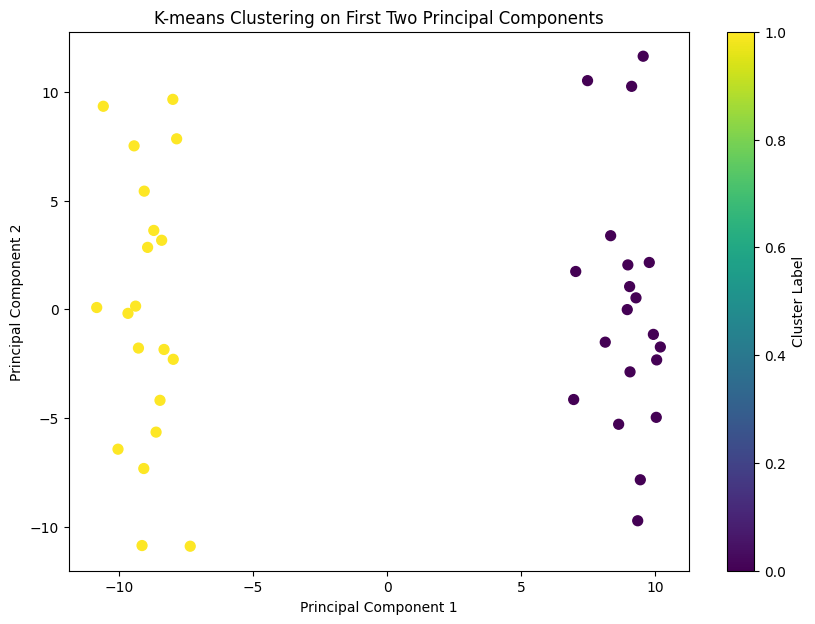

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 2: Perform PCA, reduce to first two principal components
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Step 3: Apply K-means clustering on the two principal components with K=2
kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(data_pca)

# Step 4: Calculate silhouette score
silhouette_avg = silhouette_score(data_pca, cluster_labels)

print(f"Silhouette Score: {silhouette_avg}")

# Plot the PCA result with K-means clusters
plt.figure(figsize=(10, 7))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering on First Two Principal Components')
plt.colorbar(label='Cluster Label')
plt.show()

Silhouette Score: 0.7684


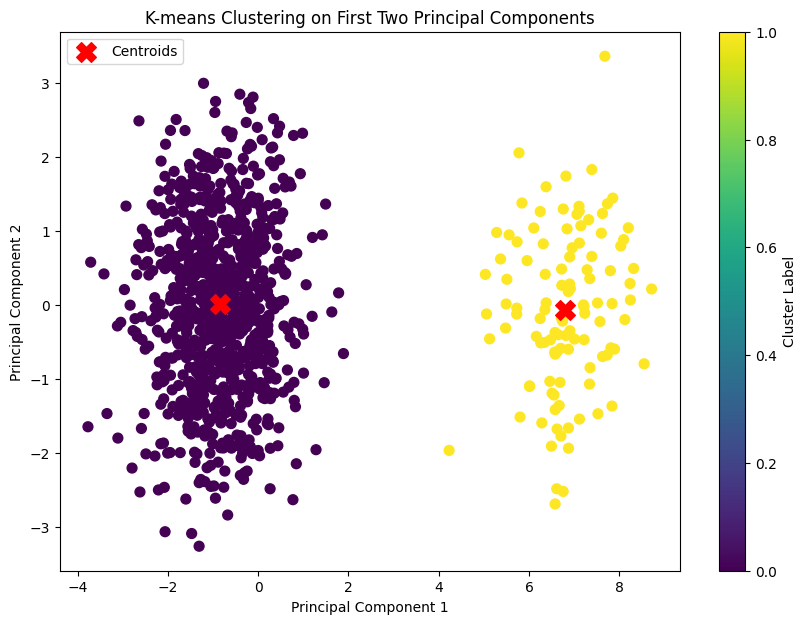

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)  # Standardize the data

# Step 2: Perform PCA, reduce to first two principal components
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Step 3: Apply K-means clustering on the two principal components with K=2
kmeans = KMeans(n_clusters=2, random_state=42)  # Use a consistent random state for reproducibility
cluster_labels = kmeans.fit_predict(data_pca)

# Step 4: Calculate silhouette score
silhouette_avg = silhouette_score(data_pca, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Step 5: Plot the PCA result with K-means clusters
plt.figure(figsize=(10, 7))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering on First Two Principal Components')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.show()

In this case, a score of 0.7684 is quite good, indicating that the clusters are well-separated and that the K-means algorithm has successfully grouped similar samples together

Interpretation:
The clustering result shows two distinct groups based on their positions in PCA space.
The separation between these two groups is clear, as indicated by both their visual separation in the plot and the relatively high silhouette score (0.7684).

Conclusion:

The K-means algorithm has successfully divided your data into two well-separated clusters based on their gene expression profiles.
The PCA transformation helped reduce dimensionality and allowed for easier visualization and clustering of your data points.